In [1]:
import pandas as pd
print(pd.__version__)

3.0.0


In [2]:
import os
print(os.getcwd())

c:\Users\mikeo


In [3]:
import os
os.chdir(r'C:\Users\mikeo\stock-eda')

In [4]:
import pandas as pd

df = pd.read_csv('all_stocks_5yr.csv')
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  str    
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 33.1 MB


In [6]:
df.describe()

,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [7]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[us]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 33.1 MB


In [8]:
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 619029 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619029 non-null  datetime64[us]
 1   open    619029 non-null  float64       
 2   high    619029 non-null  float64       
 3   low     619029 non-null  float64       
 4   close   619029 non-null  float64       
 5   volume  619029 non-null  int64         
 6   Name    619029 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 37.8 MB


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Name'].nunique()
df['Name'].unique()

<StringArray>
[ 'AAL', 'AAPL',  'AAP', 'ABBV',  'ABC',  'ABT',  'ACN', 'ADBE',  'ADI',
  'ADM',
 ...
 'XLNX',   'XL',  'XOM', 'XRAY',  'XRX',  'XYL',  'YUM',  'ZBH', 'ZION',
  'ZTS']
Length: 505, dtype: str

## DAILY RETURNS

In [11]:
df = df.sort_values(['Name', 'date'])
df['daily_return'] = df.groupby('Name')['close'].pct_change()
df.head()

,date,open,high,low,close,volume,Name,daily_return
71611,2013-02-08,45.07,45.35,45.00,45.08,1824755,A,NaN
71612,2013-02-11,45.17,45.18,44.45,44.60,2915405,A,-0.010648
71613,2013-02-12,44.81,44.95,44.50,44.62,2373731,A,0.000448
71614,2013-02-13,44.81,45.24,44.68,44.75,2052338,A,0.002913
71615,2013-02-14,44.72,44.78,44.36,44.58,3826245,A,-0.003799


In [12]:
volatility = df.groupby('Name')['daily_return'].std().sort_values(ascending=False)
volatility.head(10)

Name
CHK     0.041658
AMD     0.037784
BHGE    0.035219
FCX     0.034123
LNT     0.033373
VRTX    0.032116
INCY    0.029777
MRO     0.029739
WMB     0.029559
EVHC    0.028561
Name: daily_return, dtype: float64

Volatility measures how much the standard deviation deviates from its daily return. With volatility, you can see which stocks siwng the most. With higher swings, you can expect either high return, or high loss.

In [13]:
df['cumulative_return'] = df.groupby('Name')['daily_return'].transform(lambda x: (1 + x.fillna(0)).cumprod() - 1)

Above is the equation for cumulative return! (this took us a while to grasp.) In this line of code, we first group the dataset by the names of the companies, and then we take the daily returns of each company.  

After that, we use the 'transform' function to run the calculation after this by group. However, we want the returning value to come back in the exact same shape as it was in the original dataset.

Next, we start use a version of the cumulative return formula. First, we use the lambda function. We use this so we don't have to manually change the value of x every time we move from one company to the next. It basically inputs the each day's daily retun value into x. 

Now, the purpose of the cumulative return formula is to measure the total percentage change in the value of an investment over a specific, multi-period time frame. (the timeframe we are using is over the span of 5 years, so this works perfectly for us)
This formula is important for us because it actually shows the growth/decline of the investments with compounding effects. 

As mentioned earlier, x represents our daily returns. We add 1 to our daily returns to convert the retruns into a growth factor. If we didn't add 1, it would just be a percentage, which is not what we need for the formula. Also 'fillna(0)' is used to fill null values with 0, so it doesn't skew the data. The function cumprod() is vital for compounding. It takes the growth factors (1 + x), and multiplies them sequentially because this is what allows gains and losses to build on top of each other over time. Lastly, we use -1 to return the number back to a percentage from the growth factor. 

In [14]:
df[df['Name']=='CHK'][['date', 'cumulative_return']].tail(1)

,date,cumulative_return
115559,2018-02-07,-0.857143


In [15]:
df.groupby('Name')['cumulative_return'].last().sort_values(ascending=False).head(5)

Name
NVDA    17.496362
NFLX     9.233321
ALGN     6.159487
EA       6.084053
STZ      5.723705
Name: cumulative_return, dtype: float64

In [16]:
df[df['Name'] == 'AAPL'][['date', 'close', 'daily_return']].head(10)

,date,close,daily_return
1259,2013-02-08,67.8542,NaN
1260,2013-02-11,68.5614,0.010422
1261,2013-02-12,66.8428,-0.025067
1262,2013-02-13,66.7156,-0.001903
1263,2013-02-14,66.6556,-0.000899
1264,2013-02-15,65.7371,-0.013780
1265,2013-02-19,65.7128,-0.000370
1266,2013-02-20,64.1214,-0.024218
1267,2013-02-21,63.7228,-0.006216
1268,2013-02-22,64.4014,0.010649


## VISUALIZATION

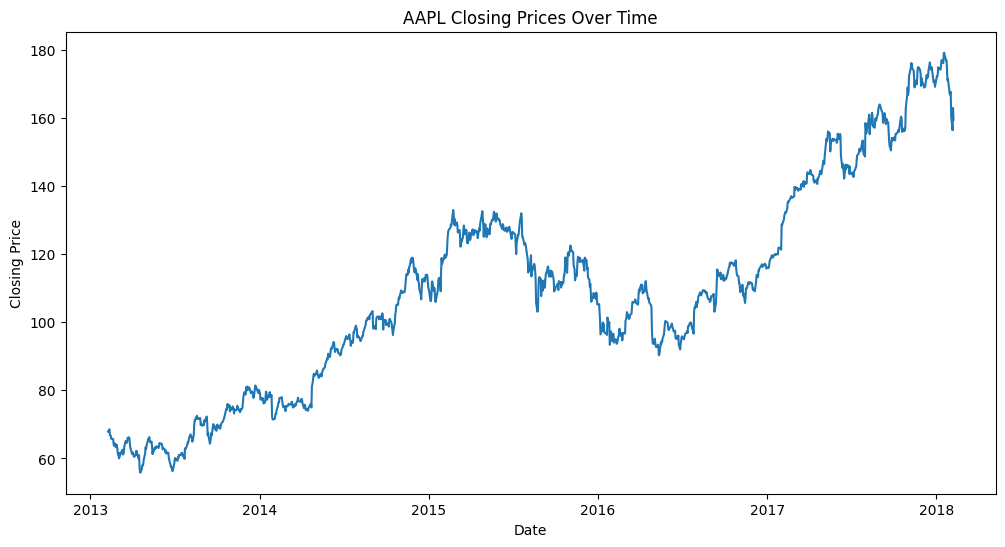

In [17]:
import matplotlib.pyplot as plt

aapl = df[df['Name'] == 'AAPL']

plt.figure(figsize=(12, 6))
plt.plot(aapl['date'], aapl['close'])
plt.title('AAPL Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

This graph shows us that over the 5 year span, the closing price of AAPL had an overall increase. It had an increase of approzimately 128%. 

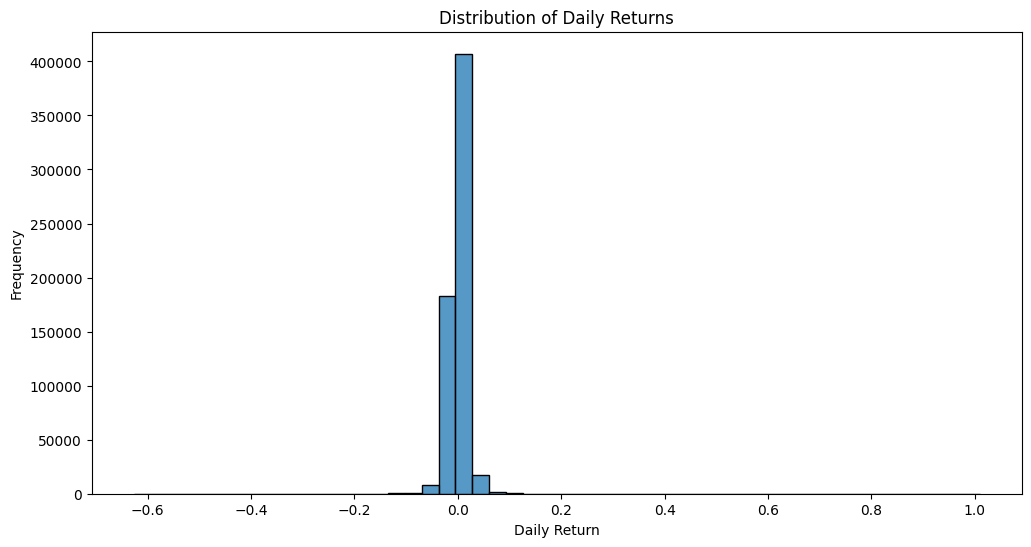

In [18]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df['daily_return'], bins=50)
plt.title('Distrubution of Daily Returns(All Stocks)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Returns')
plt.show()

This graph showcases the dispersion in the daily return of each day in the dataset. It's saying that most of the days in the dataset had daily returns that were close to 0$.

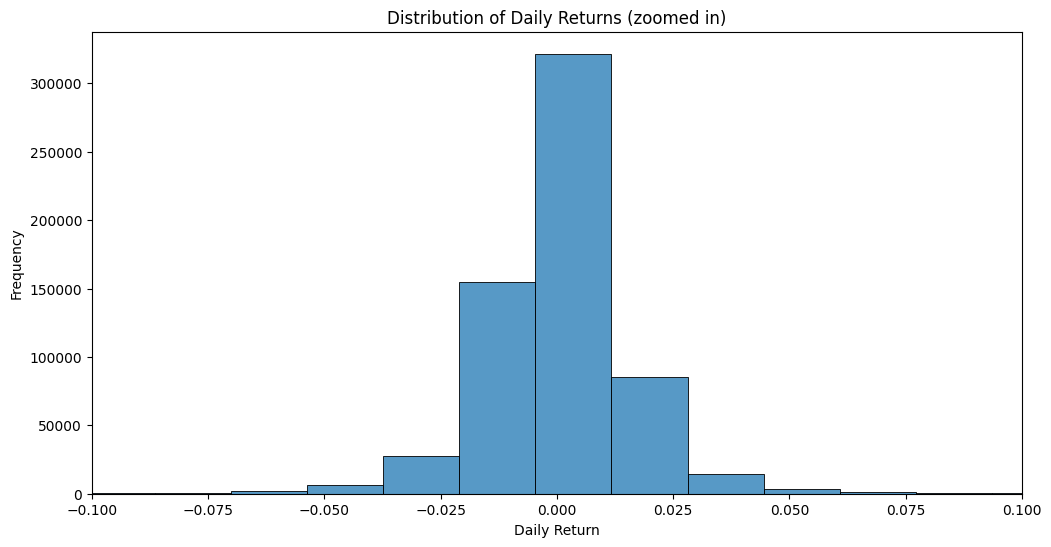

In [19]:
plt.figure(figsize=(12, 6))
sns.histplot(df['daily_return'], bins=100)
plt.title('Distribution of Daily Returns (zoomed in)')
plt.xlim(-0.1, 0.1)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

'Zoomed in' for a more detailed graph. 

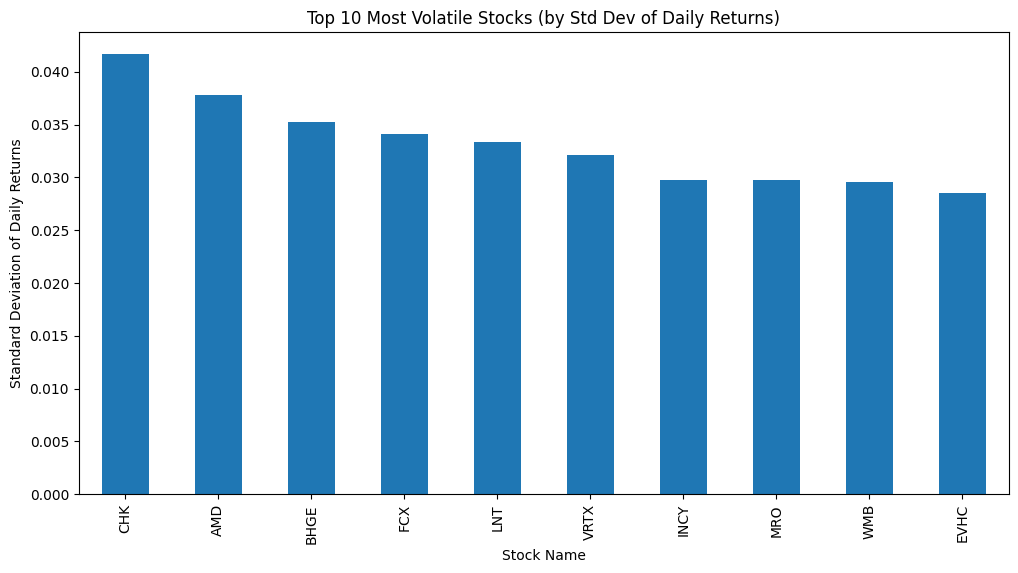

In [20]:
volatility = df.groupby('Name')['daily_return'].std().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
volatility.head(10).plot(kind='bar')
plt.title('Top 10 Most Volatile Stocks (by Std Dev of Daily Returns)')
plt.xlabel('Stock Name')
plt.ylabel('Standard Deviation of Daily Returns')
plt.show()

Here are the top 10 most volatile stocks. CHK is leading with just over 0.040 standard deviation of Daily Returns. 

We can find how much money we might gain or lose on a given day by using the number provided by the volatility chart. 

Let's say we invest $5,000. Now we can use a simple equation to find how much we might gain or lose. 

In [21]:
x = 5000 * 0.04
x

200.0

If we were to invest $5,000, we could expect to gain or lose $200 after on day of investing. 

To see the outcome behind CHK's high volatility, we can look at what actually happened to a real investment over the 5 year period. This chart shows the value of a $5,000 investment in CHK over time. This lets us see what that volatility ultimately meant for an investor's money.

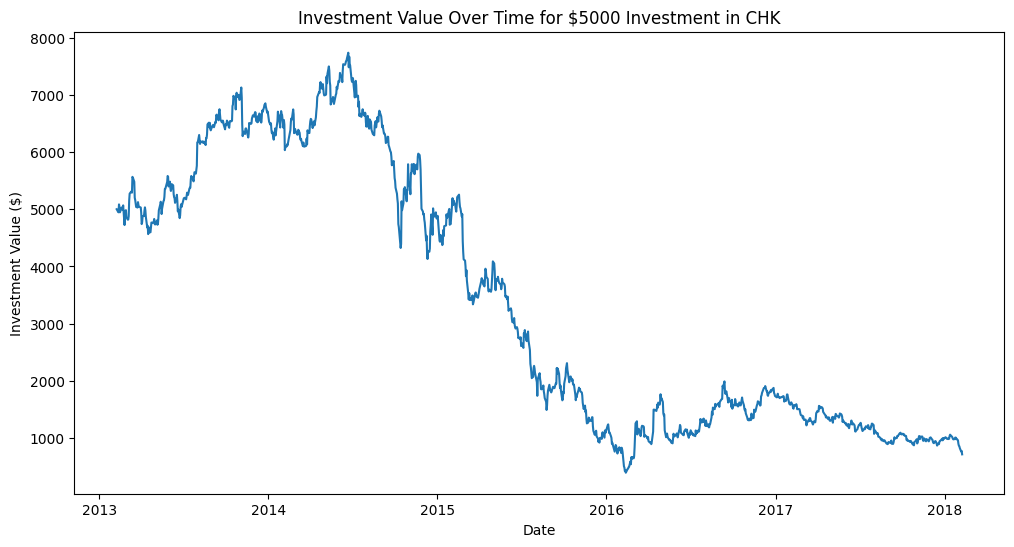

In [22]:
chk = df[df['Name'] == 'CHK']
investment_value = 5000 * (1 + chk['cumulative_return'])

plt.figure(figsize=(12, 6))
plt.plot(chk['date'], investment_value)
plt.title('Investment Value Over Time for $5000 Investment in CHK')
plt.xlabel('Date')
plt.ylabel('Investment Value ($)')
plt.show()